In [1]:
# Hanif Muflih Hidayat (13223117)
# Kuis 1 PCD
import cv2
import numpy as np
import matplotlib.pyplot as plt

Cari dan 

Shape gambar (grayscale): (4096, 3072)


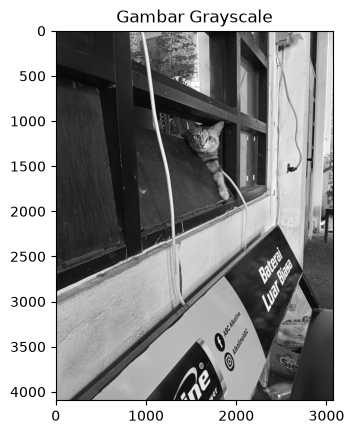

Shape gambar (grayscale): (4096, 3072)


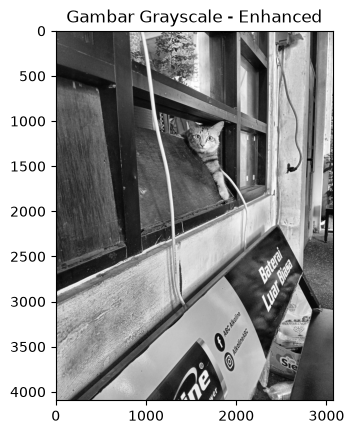

In [2]:
# Buka gambar
img = cv2.imread("kuis.jpeg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Cek gambar
print("Shape gambar (grayscale):", img_gray.shape)
plt.figure()
plt.imshow(img_gray, cmap='gray')
plt.title("Gambar Grayscale")
plt.show()

# Sedikit menaikkan kontras
hist_eq = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

gray_enhanced = hist_eq.apply(img_gray)
print("Shape gambar (grayscale):", img_gray.shape)
plt.figure()
plt.imshow(gray_enhanced, cmap='gray')
plt.title("Gambar Grayscale - Enhanced")
plt.show()

In [3]:
# Buat menjadi grid agar corner tidak bertumpuk
x_min, x_max = 0, 3000
y_min, y_max = 0, 4000

comp_img = gray_enhanced[y_min:y_max, x_min:x_max]
cell = 500

all_corners = []

# Bagi gambar sesuai grid
for y0 in range(y_min, y_max, cell):
    for x0 in range(x_min, x_max, cell):

        # Batasi pinggir
        x1 = min(x0 + cell, x_max)
        y1 = min(y0 + cell, y_max)
        comp_img = gray_enhanced[y0:y1, x0:x1]

        # Corner detection
        corners = cv2.goodFeaturesToTrack(
            comp_img,
            maxCorners=7,
            qualityLevel=0.01,
            minDistance=100,
            blockSize=7,
            useHarrisDetector=False
        )

        if corners is not None:
            for c in corners:
                x_local, y_local = c.ravel()

                x_global = x0 + x_local
                y_global = y0 + y_local

                all_corners.append([x_global, y_global])

all_corners = np.array(all_corners, dtype=np.float32)

print("Total corner:", len(all_corners))

Total corner: 336


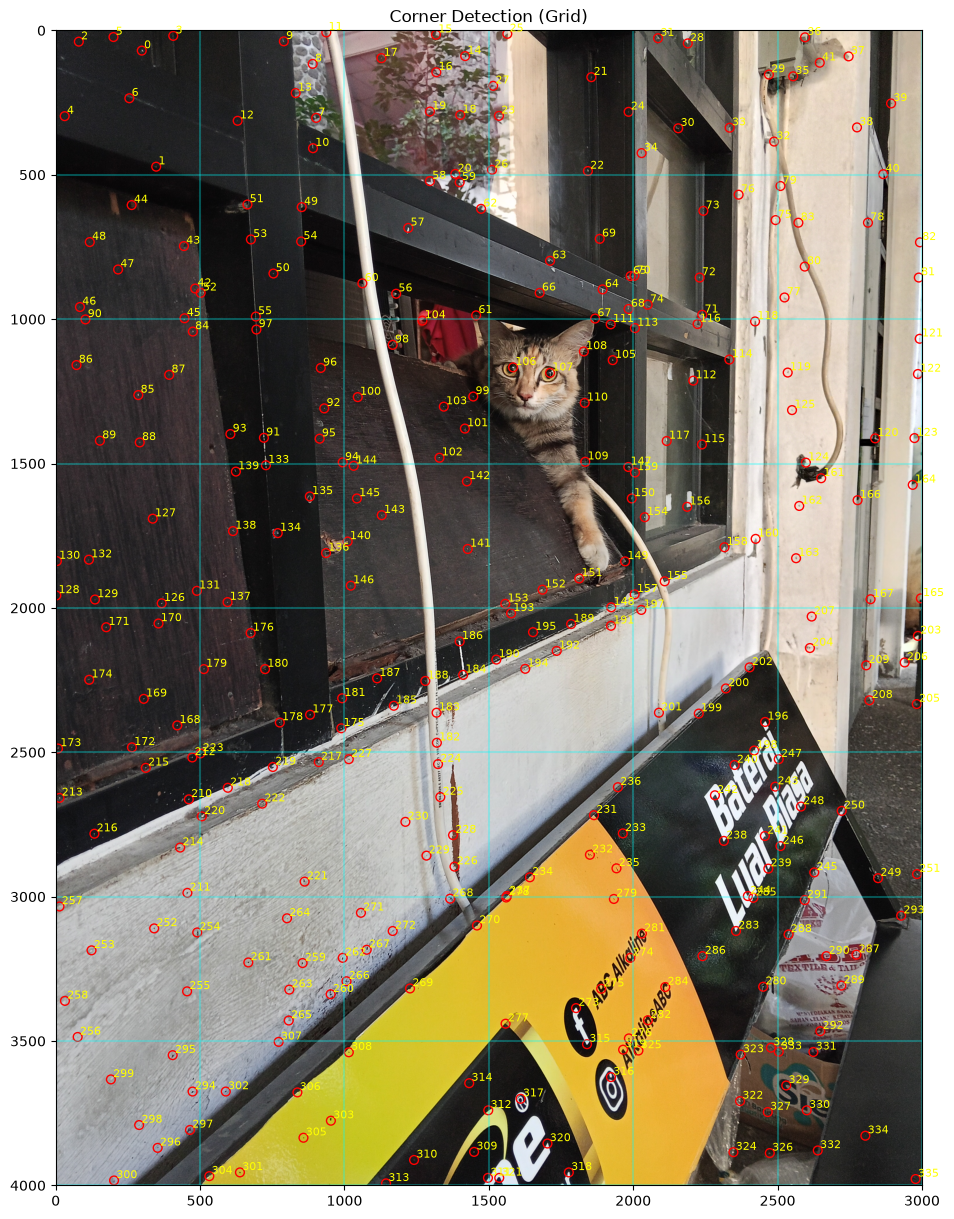

In [4]:
# Gambarkan corner yang didapat
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

for i, (x, y) in enumerate(all_corners):
    plt.scatter(
        x, y,
        s=40,
        facecolors="none",
        edgecolors="red"
    )

    plt.text(
        x + 8,
        y - 8,
        str(i),
        color="yellow",
        fontsize=8
    )

# Gambar garis grid
for x in range(x_min, x_max + 1, cell):
    plt.axvline(x, color="cyan", alpha=0.3)

for y in range(y_min, y_max + 1, cell):
    plt.axhline(y, color="cyan", alpha=0.3)

plt.xlim(x_min, x_max)
plt.ylim(y_max, y_min)

plt.title("Corner Detection (Grid)")
plt.show()

p1: (759.25, 484.00)
p2: (883.50, 2430.33)
p3: (2008.33, 922.00)
p4: (2028.67, 1900.00)
p5: (2333.00, 1140.00)
p6: (2316.00, 1790.00)
p7: (1864.00, 2718.00)
p8: (2457.00, 2395.00)
p9: (2086.00, 27.00)
p10: (2334.00, 337.00)


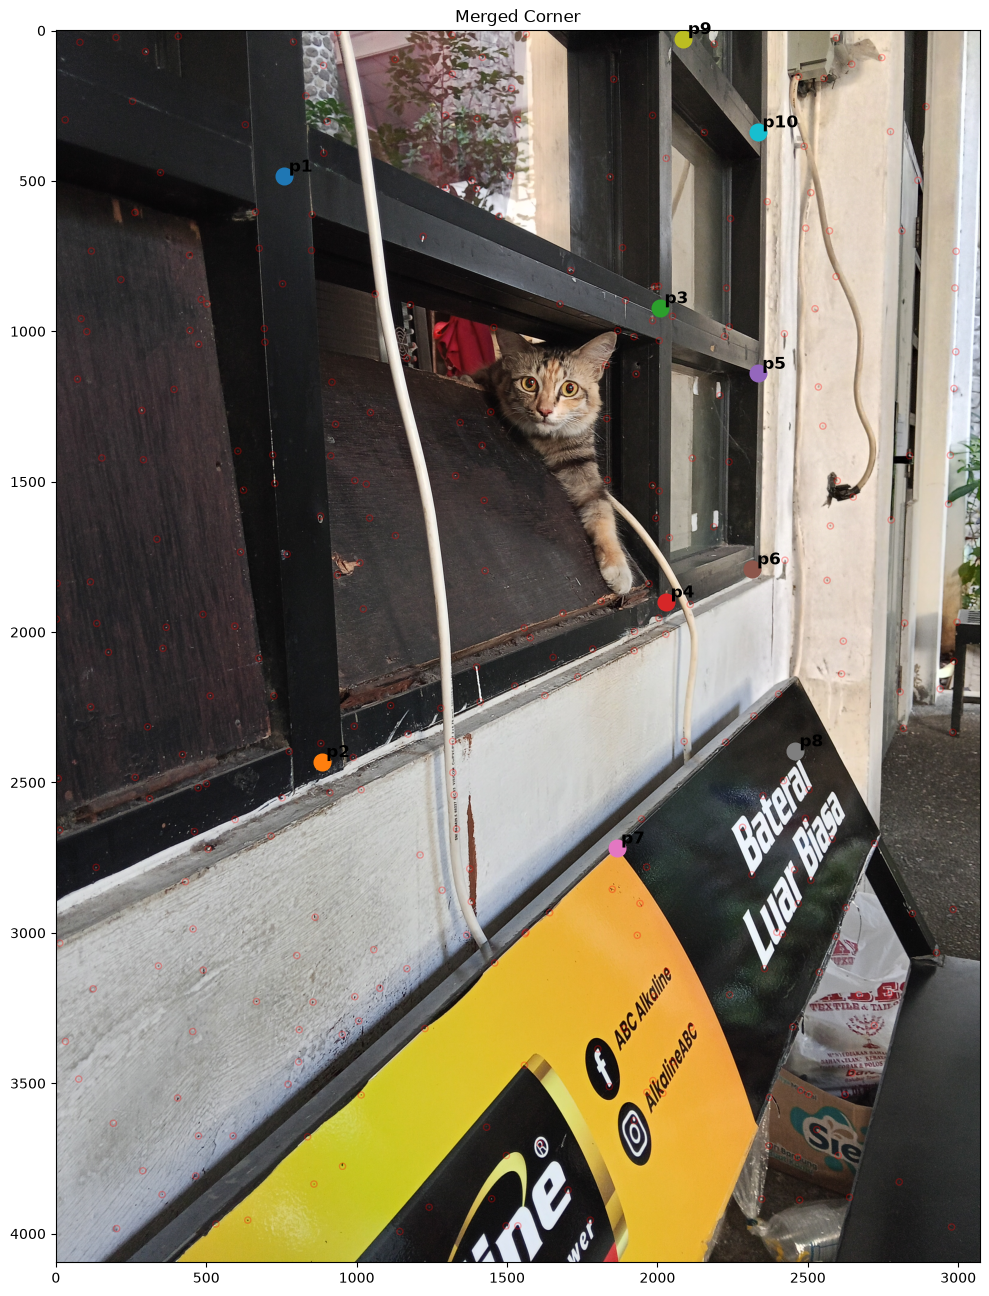

In [5]:
# Merge corner yang berdekatan untuk mendapatkan titik point 3D yang lebih sesuai
points = {
    "p1": [10, 12, 49, 51],
    "p2": [177, 178, 175, 181, 219, 217],
    "p3": [65, 68, 74],
    "p4": [149, 157, 155],
    "p5": [114],
    "p6": [158],
    "p7": [231],
    "p8": [196],
    "p9": [31],
    "p10": [33]
}

merged_points = {}
for name, ids in points.items():
    selected = all_corners[ids]

    center = np.mean(selected, axis=0)

    merged_points[name] = center

for name, (x, y) in merged_points.items():
    print(f"{name}: ({x:.2f}, {y:.2f})")

plt.figure(figsize=(12, 16))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# plot titik merged
for x, y in all_corners:
    plt.scatter(
        x, y,
        s=20,
        facecolors="none",
        edgecolors="red",
        alpha=0.3
    )

for name, (x, y) in merged_points.items():
    plt.scatter(
        x, y,
        s=100,
        marker="o",
        linewidths=3
    )

    plt.text(
        x + 15,
        y - 15,
        name,
        fontsize=12,
        weight="bold"
    )

plt.title("Merged Corner")
plt.show()

PnP

In [6]:
# Cek array yang digunakan
image2d_points = np.array(
    [merged_points[f"p{i+1}"] for i in range(10)],
    dtype=np.float64
)

object3d_points = np.array([
    [0.0, 0.0,  0.0],   # P1
    [0.0, 0.0, -0.5],   # P2
    [0.0, 1.0,  0.0],   # P3
    [0.0, 1.0, -0.5],   # P4
    [0.0, 2.0,  0.0],   # P5
    [0.0, 2.0, -0.5],   # P6
    [0.1, 0.5, -0.75],  # P7
    [0.1, 2.0, -0.75],  # P8
    [0.0, 1.0,  0.5],   # P9
    [0.0, 2.0,  0.5],   # P10
], dtype=np.float64)

print(image2d_points.shape)
print(object3d_points.shape)

(10, 2)
(10, 3)


In [7]:
# Perhitungan intrinsik kamera
W = 3072
H = 4096

f_35 = 27.0
diag_35 = np.sqrt(36**2 + 24**2)
diag_px = np.sqrt(W**2 + H**2)

f_px = f_35 * diag_px / diag_35

cx = W / 2
cy = H / 2

K = np.array([
    [f_px, 0,    cx],
    [0,    f_px, cy],
    [0,    0,    1]
], dtype=np.float64)

print("Est focal length =", f_px)
print(K)

Est focal length = 3195.0731302573195
[[3.19507313e+03 0.00000000e+00 1.53600000e+03]
 [0.00000000e+00 3.19507313e+03 2.04800000e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [8]:
# Perhitungan PnP
dist_coeffs = np.zeros((5, 1), dtype=np.float64)
ok, rot_vec, tran_vec = cv2.solvePnP(
    object3d_points,
    image2d_points,
    K,
    dist_coeffs,
    flags=cv2.SOLVEPNP_ITERATIVE
)

print("OK:", ok)
print("rotation vector:\n", rot_vec)
print("translation vector:\n", tran_vec)

OK: True
rotation vector:
 [[-4.32314943]
 [-0.94338168]
 [ 0.82467474]]
translation vector:
 [[-0.17998969]
 [-0.38566906]
 [ 0.76939947]]


In [9]:
# Dapatkan posisi kamera dan orientasinya
R, _ = cv2.Rodrigues(rot_vec)

camera_position = -R.T @ tran_vec

print("Rotation matrix:")
print(R)

print()
print("Camera position:")
print(camera_position)

R_cam_world = R.T

sy = np.sqrt(
    R_cam_world[0, 0]**2 +
    R_cam_world[1, 0]**2
)

low = sy < 1e-6

if not low:
    roll = np.arctan2(
        R_cam_world[2, 1],
        R_cam_world[2, 2]
    )

    pitch = np.arctan2(
        -R_cam_world[2, 0],
        sy
    )

    yaw = np.arctan2(
        R_cam_world[1, 0],
        R_cam_world[0, 0]
    )

else:
    roll = np.arctan2(
        -R_cam_world[1, 2],
        R_cam_world[1, 1]
    )

    pitch = np.arctan2(
        -R_cam_world[2, 0],
        sy
    )

    yaw = 0

roll_deg = round(np.degrees(roll), 3)
pitch_deg = round(np.degrees(pitch), 3)
yaw_deg = round(np.degrees(yaw), 3)

print("Roll  :", roll_deg, "deg")
print("Pitch :", pitch_deg, "deg")
print("Yaw   :", yaw_deg, "deg")

Rotation matrix:
[[ 0.90624883  0.42266978 -0.00795631]
 [ 0.06438613 -0.15660282 -0.98556075]
 [-0.41781273  0.892651   -0.16913519]]

Camera position:
[[ 0.50941208]
 [-0.67112587]
 [-0.25139981]]
Roll  : -99.738 deg
Pitch : 0.456 deg
Yaw   : 25.004 deg


Cek Proyeksi

In [10]:
projected_points, _ = cv2.projectPoints(
    object3d_points,
    rot_vec,
    tran_vec,
    K,
    dist_coeffs
)

projected_points = projected_points.reshape(-1, 2)

errors = np.linalg.norm(
    image2d_points - projected_points,
    axis=1
)

rmse = np.sqrt(np.mean(errors**2))

print("Error tiap titik:", errors)
print("RMSE:", rmse, "pixel")

Error tiap titik: [ 47.64397173  19.38257628  83.75570037  70.85879699  48.84829204
  31.4534111   25.75446997 290.4370454  100.56902703 179.08829492]
RMSE: 120.52419180569247 pixel


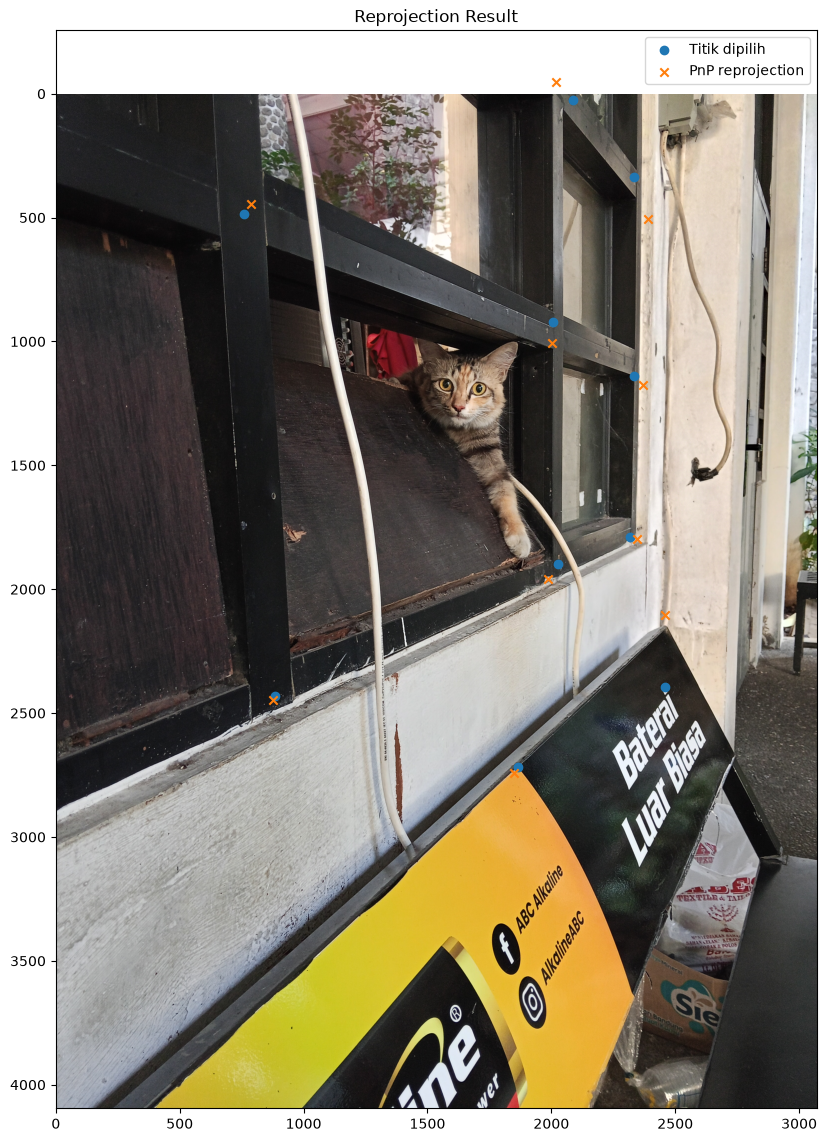

In [ ]:
# Plot hasil reprojection
plt.figure(figsize=(10, 14))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.scatter(
    image2d_points[:, 0],
    image2d_points[:, 1],
    marker="o",
    label="Titik dipilih"
)

plt.scatter(
    projected_points[:, 0],
    projected_points[:, 1],
    marker="x",
    label="PnP reprojection"
)

plt.legend()
plt.title(f"Reprojection Result")
plt.show()